# Stage 1 — Setup and data loading

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

In [29]:
df = pd.read_csv('smart_meter_ami_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)
df = df.sort_values(['Meter_ID','Timestamp']).reset_index(drop=True)

In [30]:
print(f"Total rows     : {len(df)}")
print(f"Meters         : {df['Meter_ID'].nunique()}")
print(f"Date range     : {df['Timestamp'].min()} → {df['Timestamp'].max()}")
print(f"\nStatus counts:\n{df['Status'].value_counts()}")

Total rows     : 1200
Meters         : 10
Date range     : 2026-04-01 00:00:00 → 2026-04-02 05:45:00

Status counts:
Status
OK         892
Error       75
Invalid     63
Missing     60
Anomaly     58
Outlier     52
Name: count, dtype: int64


# Stage 2 — Status filtering

In [31]:
ok_df = df[df['Status'] == 'OK'].copy().reset_index(drop = True)
fault_df = df[df['Status'] != 'OK'].copy().reset_index(drop = True)

In [32]:
print(f"OK rows    : {len(ok_df)}  ({len(ok_df)/len(df)*100:.1f}%)")
print(f"Fault rows : {len(fault_df)}  (saved for Voltage anomaly detection)")

OK rows    : 892  (74.3%)
Fault rows : 308  (saved for Voltage anomaly detection)


In [33]:
corr = ok_df[['Energy_kWh', 'Voltage_V', 'Peak_Demand_kW']].corr()
print(f"\nCorrelation matrix (OK rows only):\n{corr.round(3)}")


Correlation matrix (OK rows only):
                Energy_kWh  Voltage_V  Peak_Demand_kW
Energy_kWh           1.000      0.024           0.107
Voltage_V            0.024      1.000          -0.057
Peak_Demand_kW       0.107     -0.057           1.000


# Stage 3 — Reindex and fill missing 15-min slots

In [34]:
def reindex_meter(group):

    full_idx = pd.date_range(
        start = group['Timestamp'].min(),
        end = group['Timestamp'].max(),
        freq= '15min'
    )

    group = group.set_index('Timestamp').reindex(full_idx)
    group.index.name = 'Timestamp'

    # Forward-fill short gaps only (≤2 steps = 30 min)
    group[['Energy_kWh', 'Voltage_V', 'Peak_Demand_kW']] = (
        group[['Energy_kWh', 'Voltage_V', 'Peak_Demand_kW']]
        .ffill(limit=2)
    )
    return group.reset_index()

reindexed = []
for meter_id, group in ok_df.groupby('Meter_ID'):
    g = reindex_meter(group)
    g['Meter_ID'] = meter_id
    reindexed.append(g)

ok_reindexed = pd.concat(reindexed, ignore_index=True)
ok_reindexed = ok_reindexed.sort_values(['Meter_ID', 'Timestamp']).reset_index(drop=True)

print(f"Rows after reindex: {len(ok_reindexed)}")
print(f"Remaining NaN (Energy): {ok_reindexed['Energy_kWh'].isna().sum()}")

Rows after reindex: 1195
Remaining NaN (Energy): 24


# Stage 4 — Feature engineering

In [35]:
def add_calendar_features(df):
    df = df.copy()
    
    df['hour'] = df['Timestamp'].dt.hour
    df['minute'] = df['Timestamp'].dt.minute
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['hour_block'] = df['hour'] // 6
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['is_peak_hour']  = df['hour'].isin([7, 8, 9, 18, 19, 20]).astype(int)
    return df
    
ok_reindexed = add_calendar_features(ok_reindexed)

In [36]:
def add_lag_features(df, target_col, lags):
    """
    Add lag features within each meter group.
    lags: list of integer steps (1 step = 15 min)
    """
    df = df.copy()
    for lag in lags:
        col_name = f'{target_col}_lag_{lag}'
        df[col_name] = df.groupby('Meter_ID')[target_col].shift(lag)
    return df

# Lags for Energy: 15 min, 30 min, 1 hour, 2 hours back
ok_reindexed = add_lag_features(ok_reindexed, 'Energy_kWh',
                                 lags=[1, 2, 4, 8])

# Lags for Demand (will be used in Demand model)
ok_reindexed = add_lag_features(ok_reindexed, 'Peak_Demand_kW',
                                 lags=[1, 2, 4, 8])

In [37]:
def add_rolling_features(df, target_col, windows):
    """
    Rolling mean and std within each meter group.
    windows: list of integer step sizes
    """
    df = df.copy()
    for w in windows:
        grp = df.groupby('Meter_ID')[target_col]
        df[f'{target_col}_roll_mean_{w}'] = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean()
        )
        df[f'{target_col}_roll_std_{w}'] = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).std()
        )
    return df

# Windows: 4 steps (1h) and 8 steps (2h)
ok_reindexed = add_rolling_features(ok_reindexed, 'Energy_kWh',    windows=[4, 8])
ok_reindexed = add_rolling_features(ok_reindexed, 'Peak_Demand_kW', windows=[4, 8])

In [38]:
ok_reindexed = pd.get_dummies(ok_reindexed, columns=['Meter_ID'], prefix='meter')
print("Meter dummy columns:", [c for c in ok_reindexed.columns if c.startswith('meter_')])

Meter dummy columns: ['meter_SM001', 'meter_SM002', 'meter_SM003', 'meter_SM004', 'meter_SM005', 'meter_SM006', 'meter_SM007', 'meter_SM008', 'meter_SM009', 'meter_SM010']


In [39]:
drop_cols_check = (
    [c for c in ok_reindexed.columns if '_lag_' in c or '_roll_' in c]
    + ['Energy_kWh', 'Peak_Demand_kW']      # ← targets must be included
)

ok_reindexed = ok_reindexed.dropna(subset=drop_cols_check).reset_index(drop=True)

print(f"Rows after clean dropna : {len(ok_reindexed)}")
print(f"Energy NaN remaining    : {ok_reindexed['Energy_kWh'].isna().sum()}")
print(f"Demand NaN remaining    : {ok_reindexed['Peak_Demand_kW'].isna().sum()}")

Rows after clean dropna : 1012
Energy NaN remaining    : 0
Demand NaN remaining    : 0


# Stage 5 — Feature matrix definition

In [40]:
calendar_features = [
    'hour', 'minute', 'day_of_week', 'is_weekend',
    'hour_block', 'hour_sin', 'hour_cos', 'is_peak_hour'
]

meter_features = [c for c in ok_reindexed.columns if c.startswith('meter_')]

energy_lag_features = [
    'Energy_kWh_lag_1', 'Energy_kWh_lag_2',
    'Energy_kWh_lag_4', 'Energy_kWh_lag_8',
    'Energy_kWh_roll_mean_4', 'Energy_kWh_roll_std_4',
    'Energy_kWh_roll_mean_8', 'Energy_kWh_roll_std_8',
]

demand_lag_features = [
    'Peak_Demand_kW_lag_1', 'Peak_Demand_kW_lag_2',
    'Peak_Demand_kW_lag_4', 'Peak_Demand_kW_lag_8',
    'Peak_Demand_kW_roll_mean_4', 'Peak_Demand_kW_roll_std_4',
    'Peak_Demand_kW_roll_mean_8', 'Peak_Demand_kW_roll_std_8',
]

# ── Energy model features ──────────────────────────────────────────────────────
ENERGY_FEATURES = calendar_features + meter_features + energy_lag_features

# ── Demand model features (Energy added as predictor — 0.65-0.84 corr per meter)
DEMAND_FEATURES = calendar_features + meter_features + demand_lag_features + \
                  ['Energy_kWh'] + energy_lag_features

print(f"Energy model feature count : {len(ENERGY_FEATURES)}")
print(f"Demand model feature count : {len(DEMAND_FEATURES)}")

Energy model feature count : 26
Demand model feature count : 35


# Stage 6 — Train / validation / test split (chronological)

In [41]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
  
    df = df.sort_values('Timestamp').reset_index(drop=True)
    n = len(df)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))

    train = df.iloc[:train_end]
    val   = df.iloc[train_end:val_end]
    test  = df.iloc[val_end:]
    return train, val, test

train_df, val_df, test_df = chronological_split(ok_reindexed)

print(f"Train : {len(train_df)} rows  ({train_df['Timestamp'].min()} → {train_df['Timestamp'].max()})")
print(f"Val   : {len(val_df)} rows  ({val_df['Timestamp'].min()} → {val_df['Timestamp'].max()})")
print(f"Test  : {len(test_df)} rows  ({test_df['Timestamp'].min()} → {test_df['Timestamp'].max()})")

Train : 708 rows  (2026-04-01 02:00:00 → 2026-04-01 21:45:00)
Val   : 152 rows  (2026-04-01 21:45:00 → 2026-04-02 01:45:00)
Test  : 152 rows  (2026-04-02 01:45:00 → 2026-04-02 05:45:00)


In [42]:
print(f"NaNs in y_train: {y_train_e.isna().sum()}")
print(f"NaNs in y_val:   {y_val_e.isna().sum()}")
print(f"Infs in y_train: {np.isinf(y_train_e).sum()}")

NaNs in y_train: 14
NaNs in y_val:   1
Infs in y_train: 0


# Stage 7 — Model training

In [43]:
X_train_e = train_df[ENERGY_FEATURES]
y_train_e = train_df['Energy_kWh']

X_val_e   = val_df[ENERGY_FEATURES]
y_val_e   = val_df['Energy_kWh']

X_test_e  = test_df[ENERGY_FEATURES]
y_test_e  = test_df['Energy_kWh']

energy_model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,    # L1 regularisation
    reg_lambda        = 1.0,    # L2 regularisation
    early_stopping_rounds = 30,
    eval_metric       = 'mae',
    random_state      = 42,
    verbosity         = 0
)

energy_model.fit(
    X_train_e, y_train_e,
    eval_set=[(X_val_e, y_val_e)],
    verbose=False
)

print(f"Best iteration: {energy_model.best_iteration}")

Best iteration: 7


In [44]:
X_train_d = train_df[DEMAND_FEATURES]
y_train_d = train_df['Peak_Demand_kW']

X_val_d   = val_df[DEMAND_FEATURES]
y_val_d   = val_df['Peak_Demand_kW']

X_test_d  = test_df[DEMAND_FEATURES]
y_test_d  = test_df['Peak_Demand_kW']

demand_model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    early_stopping_rounds = 30,
    eval_metric       = 'mae',
    random_state      = 42,
    verbosity         = 0
)

demand_model.fit(
    X_train_d, y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=False
)

print(f"Best iteration: {demand_model.best_iteration}")

Best iteration: 60


# Stage 8 — Evaluation

In [45]:
def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    # sMAPE: symmetric — handles near-zero values safely
    smape = 100 * np.mean(
        2 * np.abs(preds - y_test) / (np.abs(preds) + np.abs(y_test) + 1e-8)
    )
    print(f"\n── {label} ──")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  sMAPE : {smape:.2f}%")
    return preds

energy_preds = evaluate(energy_model, X_test_e, y_test_e, "Energy_kWh   (1-step)")
demand_preds = evaluate(demand_model, X_test_d, y_test_d, "Peak_Demand_kW (1-step)")


── Energy_kWh   (1-step) ──
  MAE   : 0.2522
  RMSE  : 0.3045
  sMAPE : 22.37%

── Peak_Demand_kW (1-step) ──
  MAE   : 0.3705
  RMSE  : 0.4656
  sMAPE : 10.78%


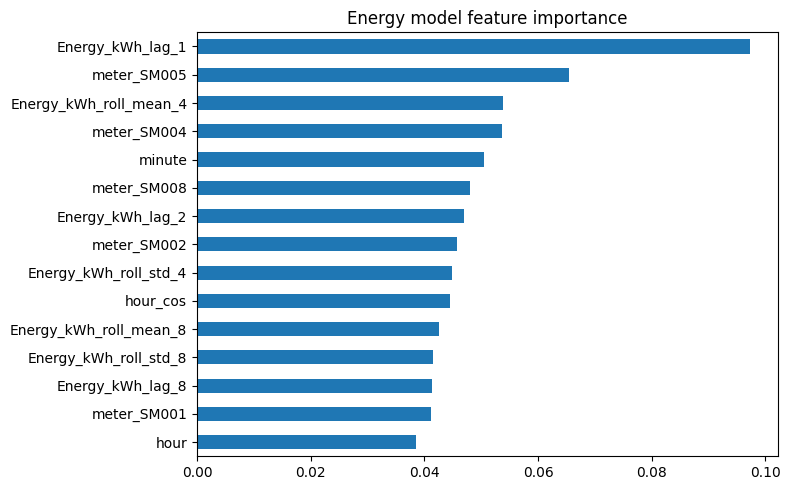

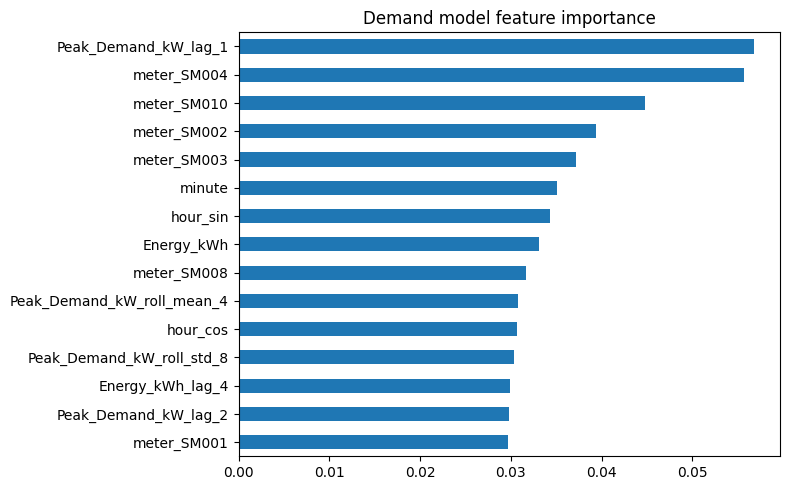

In [46]:
import matplotlib.pyplot as plt

def plot_importance(model, features, title, top_n=15):
    imp = pd.Series(model.feature_importances_, index=features)
    imp = imp.sort_values(ascending=True).tail(top_n)
    imp.plot(kind='barh', figsize=(8, 5), title=title)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_importance.png", dpi=120)
    plt.show()

plot_importance(energy_model, ENERGY_FEATURES,  "Energy model feature importance")
plot_importance(demand_model, DEMAND_FEATURES,  "Demand model feature importance")

# Stage 9 — Voltage anomaly detection (rule-based)

In [47]:
# Compute per-meter voltage band from OK data
voltage_bands = ok_df.groupby('Meter_ID')['Voltage_V'].agg(['mean', 'std'])
voltage_bands['lower'] = voltage_bands['mean'] - 2 * voltage_bands['std']
voltage_bands['upper'] = voltage_bands['mean'] + 2 * voltage_bands['std']
print("Voltage bands per meter (±2σ):")
print(voltage_bands.round(2))

# Flag anomalies in the full dataset
def flag_voltage(row):
    band = voltage_bands.loc[row['Meter_ID']]
    if pd.isna(row['Voltage_V']):
        return 'missing'
    elif row['Voltage_V'] < band['lower'] or row['Voltage_V'] > band['upper']:
        return 'anomaly'
    else:
        return 'normal'

df['voltage_flag'] = df.apply(flag_voltage, axis=1)
print(f"\nVoltage flag counts:\n{df['voltage_flag'].value_counts()}")

Voltage bands per meter (±2σ):
            mean   std   lower   upper
Meter_ID                              
SM001     228.92  4.92  219.08  238.76
SM002     229.40  5.03  219.34  239.46
SM003     228.92  5.63  217.66  240.18
SM004     229.40  4.82  219.76  239.04
SM005     229.94  4.93  220.09  239.79
SM006     229.43  5.35  218.72  240.13
SM007     228.63  5.27  218.08  239.18
SM008     229.23  5.67  217.89  240.56
SM009     229.39  4.53  220.33  238.45
SM010     228.76  5.28  218.19  239.32

Voltage flag counts:
voltage_flag
normal     1034
anomaly      91
missing      75
Name: count, dtype: int64


# Stage 10 — Saving models and outputs

In [49]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(energy_model, 'models/energy_xgb_1step.pkl')
joblib.dump(demand_model, 'models/demand_xgb_1step.pkl')

# Save anomaly data for future Voltage detector training
fault_df.to_csv('data/fault_rows_for_anomaly_training.csv', index=False)
voltage_bands.to_csv('data/voltage_bands_per_meter.csv')

print("Models and data saved.")

Models and data saved.


# Stage 11 — Rolling forecast in production

In [51]:
energy_model = joblib.load("models/energy_xgb_1step.pkl")
demand_model = joblib.load("models/demand_xgb_1step.pkl")
print("✓ Models loaded.")

✓ Models loaded.


In [52]:
def build_next_step_features(last_row, next_ts):
    feat = {}

    # Calendar features from t+1
    feat["hour"]         = next_ts.hour
    feat["minute"]       = next_ts.minute
    feat["day_of_week"]  = next_ts.dayofweek
    feat["is_weekend"]   = int(next_ts.dayofweek >= 5)
    feat["hour_block"]   = next_ts.hour // 6
    feat["hour_sin"]     = np.sin(2 * np.pi * next_ts.hour / 24)
    feat["hour_cos"]     = np.cos(2 * np.pi * next_ts.hour / 24)
    feat["is_peak_hour"] = int(next_ts.hour in [7, 8, 9, 18, 19, 20])

    for col in meter_features:
        feat[col] = int(last_row[col]) if col in last_row.index else 0

    # Energy lags: shift forward by 1 step
    feat["Energy_kWh_lag_1"] = last_row["Energy_kWh"]
    feat["Energy_kWh_lag_2"] = last_row.get("Energy_kWh_lag_1", last_row["Energy_kWh"])
    feat["Energy_kWh_lag_4"] = last_row.get("Energy_kWh_lag_2", last_row["Energy_kWh"])
    feat["Energy_kWh_lag_8"] = last_row.get("Energy_kWh_lag_4", last_row["Energy_kWh"])

    # Energy rolling stats (carry forward)
    feat["Energy_kWh_roll_mean_4"] = last_row.get("Energy_kWh_roll_mean_4", 0)
    feat["Energy_kWh_roll_std_4"]  = last_row.get("Energy_kWh_roll_std_4", 0)
    feat["Energy_kWh_roll_mean_8"] = last_row.get("Energy_kWh_roll_mean_8", 0)
    feat["Energy_kWh_roll_std_8"]  = last_row.get("Energy_kWh_roll_std_8", 0)

    # Demand lags: shift forward by 1 step
    feat["Peak_Demand_kW_lag_1"] = last_row["Peak_Demand_kW"]
    feat["Peak_Demand_kW_lag_2"] = last_row.get("Peak_Demand_kW_lag_1", last_row["Peak_Demand_kW"])
    feat["Peak_Demand_kW_lag_4"] = last_row.get("Peak_Demand_kW_lag_2", last_row["Peak_Demand_kW"])
    feat["Peak_Demand_kW_lag_8"] = last_row.get("Peak_Demand_kW_lag_4", last_row["Peak_Demand_kW"])

    # Demand rolling stats (carry forward)
    feat["Peak_Demand_kW_roll_mean_4"] = last_row.get("Peak_Demand_kW_roll_mean_4", 0)
    feat["Peak_Demand_kW_roll_std_4"]  = last_row.get("Peak_Demand_kW_roll_std_4", 0)
    feat["Peak_Demand_kW_roll_mean_8"] = last_row.get("Peak_Demand_kW_roll_mean_8", 0)
    feat["Peak_Demand_kW_roll_std_8"]  = last_row.get("Peak_Demand_kW_roll_std_8", 0)

    feat["Energy_kWh"] = last_row["Energy_kWh"]
    return feat

In [53]:
results = []
meter_cols = sorted([c for c in ok_reindexed.columns if c.startswith("meter_")])

for mcol in meter_cols:
    meter_id = mcol.replace("meter_", "")
    mask = ok_reindexed[mcol] == True
    meter_df = ok_reindexed[mask].sort_values("Timestamp")

    if meter_df.empty:
        continue

    last_row = meter_df.iloc[-1]
    last_ts  = last_row["Timestamp"]
    next_ts  = last_ts + pd.Timedelta(minutes=15)

    feat_dict = build_next_step_features(last_row, next_ts)
    row_df = pd.DataFrame([feat_dict])

    for col in ENERGY_FEATURES + DEMAND_FEATURES:
        if col not in row_df.columns:
            row_df[col] = 0

    energy_pred = energy_model.predict(row_df[ENERGY_FEATURES])[0]
    demand_pred = demand_model.predict(row_df[DEMAND_FEATURES])[0]

    results.append({
        "Meter_ID":                 meter_id,
        "Last_Known_Timestamp":     last_ts,
        "Predicted_Timestamp":      next_ts,
        "Last_Energy_kWh":          round(float(last_row["Energy_kWh"]), 4),
        "Predicted_Energy_kWh":     round(float(energy_pred), 4),
        "Last_Peak_Demand_kW":      round(float(last_row["Peak_Demand_kW"]), 4),
        "Predicted_Peak_Demand_kW": round(float(demand_pred), 4),
    })

results_df = pd.DataFrame(results)

print("  NEXT-STEP (t+15 min) PREDICTIONS FOR ALL METERS")
print(results_df.to_string(index=False))

results_df.to_csv("data/next_step_predictions.csv", index=False)
print("\n✓ Predictions saved to data/next_step_predictions.csv")


  NEXT-STEP (t+15 min) PREDICTIONS FOR ALL METERS
Meter_ID Last_Known_Timestamp Predicted_Timestamp  Last_Energy_kWh  Predicted_Energy_kWh  Last_Peak_Demand_kW  Predicted_Peak_Demand_kW
   SM001  2026-04-02 05:45:00 2026-04-02 06:00:00             0.96                1.1804                 3.40                    3.4819
   SM002  2026-04-02 05:30:00 2026-04-02 05:45:00             1.26                1.1966                 2.82                    3.3863
   SM003  2026-04-02 05:45:00 2026-04-02 06:00:00             0.92                1.1910                 3.07                    3.3290
   SM004  2026-04-02 05:45:00 2026-04-02 06:00:00             1.21                1.2096                 3.88                    3.7133
   SM005  2026-04-02 05:45:00 2026-04-02 06:00:00             1.34                1.2397                 2.64                    3.1557
   SM006  2026-04-02 05:30:00 2026-04-02 05:45:00             1.27                1.1928                 3.69                    3.478